27/05

In [4]:
import os
import glob
import pandas as pd
import numpy as np

print("AUDITORIA FÍSICA E TEMPORAL DOS DADOS BRUTOS")

# 1. Definição do caminho da pasta de dados brutos
PASTA_RAW = '/workspaces/EyeTracking/data/raw/'

# Procurar todos os arquivos Excel na pasta
arquivos_raw = glob.glob(os.path.join(PASTA_RAW, '*.xlsx'))

if not arquivos_raw:
    print(f" Nenhum arquivo encontrado na pasta: {PASTA_RAW}")
    print("Verifique se os arquivos foram transferidos corretamente para o novo repositório.")
else:
    print(f" Foram encontrados {len(arquivos_raw)} arquivos. Iniciando inspeção profunda...\n")
    
    # Lista para armazenar o diagnóstico de cada paciente
    auditoria = []

    for caminho in arquivos_raw:
        nome_arquivo = os.path.basename(caminho)
        nome_puro = nome_arquivo.replace('.xlsx', '')
        grupo = "TEA" if "TEA" in nome_puro.upper() else "CONTROLE"
        
        # Tamanho físico real no disco
        tamanho_kb = os.path.getsize(caminho) / 1024
        
        try:
            # Lendo o Excel bruto
            df = pd.read_excel(caminho)
            total_linhas = len(df)
            
            # Avaliação da Estabilidade Temporal
            # Procurando a coluna de tempo. O padrão costuma ser 'Time (ms)' ou 'Time'
            coluna_tempo = [col for col in df.columns if 'time' in col.lower()]
            
            if coluna_tempo:
                # Se a coluna existir, calculamos a diferença de tempo entre uma linha e a próxima
                vetor_tempo = df[coluna_tempo[0]].dropna()
                diferencas_tempo = vetor_tempo.diff().dropna()
                
                # Média do salto temporal e Desvio Padrão (Jitter)
                media_gap = diferencas_tempo.mean()
                jitter_std = diferencas_tempo.std()
            else:
                media_gap = np.nan
                jitter_std = np.nan
                
            status_leitura = "OK"
            
        except Exception as e:
            total_linhas = 0
            media_gap = np.nan
            jitter_std = np.nan
            status_leitura = f"Erro: {str(e)[:20]}"
            
        # Guardar as informações na matriz de auditoria
        auditoria.append({
            'Paciente': nome_puro,
            'Grupo': grupo,
            'Tamanho (KB)': round(tamanho_kb, 1),
            'Total Linhas (Brutas)': total_linhas,
            'Média Timegap (ms)': round(media_gap, 2) if pd.notnull(media_gap) else 'N/A',
            'Jitter / Desvio (ms)': round(jitter_std, 2) if pd.notnull(jitter_std) else 'N/A',
            'Status': status_leitura
        })

    # Transformar a lista num DataFrame (Tabela) para visualização
    df_auditoria = pd.DataFrame(auditoria)
    
    # Ordenar por Grupo e depois pelo número de linhas
    df_auditoria = df_auditoria.sort_values(by=['Grupo', 'Total Linhas (Brutas)'], ascending=[True, False]).reset_index(drop=True)
    
    # Exibir a tabela no notebook
    display(df_auditoria)
    
    print("INSPEÇÃO CONCLUÍDA.")

AUDITORIA FÍSICA E TEMPORAL DOS DADOS BRUTOS
 Foram encontrados 41 arquivos. Iniciando inspeção profunda...



,Paciente,Grupo,Tamanho (KB),Total Linhas (Brutas),Média Timegap (ms),Jitter / Desvio (ms),Status
0,T51 CONTROLE,CONTROLE,791.2,12056,16.91,5.80,OK
1,T34 CONTROLE,CONTROLE,799.3,12002,16.99,9.76,OK
2,T48 CONTROLE,CONTROLE,774.3,11965,17.04,6.09,OK
3,T47 CONTROLE,CONTROLE,778.8,11951,16.99,9.42,OK
4,T39 CONTROLE,CONTROLE,804.3,11941,17.08,8.39,OK
5,T49 CONTROLE,CONTROLE,774.7,11907,17.12,7.24,OK
6,T60 CONTROLE,CONTROLE,784.0,11899,17.14,6.54,OK
7,T58 CONTROLE,CONTROLE,779.9,11877,17.17,17.71,OK
8,T56 CONTROLE,CONTROLE,766.9,11849,17.21,11.02,OK
9,T37 CONTROLE,CONTROLE,782.2,11832,17.24,10.66,OK


INSPEÇÃO CONCLUÍDA.


In [ ]:
import os
import glob
import pandas as pd
import numpy as np

print("LIMPEZA E PADRONIZAÇÃO ESTRUTURAL")

# 1. Definição de Caminhos e Regras
PASTA_RAW = '/workspaces/EyeTracking/data/raw/'
PASTA_LIMPOS = '/workspaces/EyeTracking/data/csv/'
os.makedirs(PASTA_LIMPOS, exist_ok=True)

# A barreira de contenção intransponível
EXCLUSOES_DEFINITIVAS = ['T12', 'T15', 'T42']

# 2. Busca e Filtragem Inicial
arquivos_raw = glob.glob(os.path.join(PASTA_RAW, '*.xlsx'))
arquivos_validos = []

for caminho in arquivos_raw:
    nome_puro = os.path.basename(caminho).replace('.xlsx', '')
    
    # Se o nome contiver algum dos padrões de exclusão, ignoramos.
    ignorar = False
    for excluido in EXCLUSOES_DEFINITIVAS:
        if excluido in nome_puro:
            ignorar = True
            break
            
    if ignorar:
        print(f" BLOQUEADO: O arquivo '{nome_puro}' foi retido na barreira de exclusão.")
    else:
        arquivos_validos.append(caminho)

print(f"\n Total de pacientes liberados para limpeza: {len(arquivos_validos)} (Alvo: 38)")
print("Iniciando a padronização e conversão para CSV...\n")

# 3. Motor de Higienização
contador_sucesso = 0

for caminho in arquivos_validos:
    nome_arquivo = os.path.basename(caminho)
    nome_puro = nome_arquivo.replace('.xlsx', '')
    
    try:
        # Lemos os dados brutos
        df = pd.read_excel(caminho)
        
        # --- A. MAPEAMENTO DE COLUNAS (Expressões Regulares) ---
        # Converte tudo para minúsculas temporariamente para facilitar a busca
        colunas_lower = {col: col.lower() for col in df.columns}
        mapa_colunas = {}
        
        for col_original, col_low in colunas_lower.items():
            if 'time' in col_low and 'gap' not in col_low:
                mapa_colunas['Time'] = col_original
            elif 'gap' in col_low or 'interval' in col_low:
                mapa_colunas['Timegap'] = col_original
            elif 'x' in col_low and ('gaze' in col_low or 'porcentagem' in col_low):
                mapa_colunas['Gaze_X'] = col_original
            elif 'y' in col_low and ('gaze' in col_low or 'porcentagem' in col_low):
                mapa_colunas['Gaze_Y'] = col_original
            elif 'aoi' in col_low or 'area' in col_low:
                mapa_colunas['AOI'] = col_original
            elif any(termo in col_low for termo in ['pupil', 'pupila', 'size', 'diameter']):
                # Garante que pega a primeira coluna de pupila (caso haja do olho esquerdo e direito, focaremos numa)
                if 'Pupil' not in mapa_colunas:
                    mapa_colunas['Pupil'] = col_original

        # Cria um novo DataFrame apenas com as colunas que importam, padronizadas
        df_limpo = pd.DataFrame()
        df_limpo['Time (ms)'] = df[mapa_colunas['Time']] if 'Time' in mapa_colunas else np.nan
        df_limpo['Timegap (ms)'] = df[mapa_colunas['Timegap']] if 'Timegap' in mapa_colunas else np.nan
        df_limpo['Gaze X'] = df[mapa_colunas['Gaze_X']] if 'Gaze_X' in mapa_colunas else np.nan
        df_limpo['Gaze Y'] = df[mapa_colunas['Gaze_Y']] if 'Gaze_Y' in mapa_colunas else np.nan
        
        # APupilometria é bônus, se não achar, preenche com NaN
        df_limpo['Pupil_Size'] = df[mapa_colunas['Pupil']] if 'Pupil' in mapa_colunas else np.nan
        
        # Se AOI não for encontrado, assume 0
        df_limpo['AOI'] = df[mapa_colunas['AOI']] if 'AOI' in mapa_colunas else 0

        # --- B. PRESERVAÇÃO DA LINHA DO TEMPO E TRATAMENTO DE RUÍDO ---
        # Garantir que Time e Timegap são numéricos
        df_limpo['Time (ms)'] = pd.to_numeric(df_limpo['Time (ms)'], errors='coerce')
        df_limpo['Timegap (ms)'] = pd.to_numeric(df_limpo['Timegap (ms)'], errors='coerce')
        df_limpo['AOI'] = pd.to_numeric(df_limpo['AOI'], errors='coerce').fillna(0).astype(int)
        
        # Identificar linhas onde o olho sumiu (Gaze X ou Y não numéricos ou nulos)
        df_limpo['Gaze X'] = pd.to_numeric(df_limpo['Gaze X'], errors='coerce')
        df_limpo['Gaze Y'] = pd.to_numeric(df_limpo['Gaze Y'], errors='coerce')
        
        mascara_ruido = df_limpo['Gaze X'].isnull() | df_limpo['Gaze Y'].isnull()
        
        # Nas linhas de ruído, forçamos o AOI a ser 0 (Nenhuma Área de Interesse Válida)
        df_limpo.loc[mascara_ruido, 'AOI'] = 0
        
        # (Opcional, mas seguro): Remover linhas onde o TEMPO não existe (isso sim é um erro fatal)
        df_limpo = df_limpo.dropna(subset=['Time (ms)'])

        # --- C. EXPORTAÇÃO ---
        caminho_csv = os.path.join(PASTA_LIMPOS, f"{nome_puro}.csv")
        df_limpo.to_csv(caminho_csv, index=False)
        contador_sucesso += 1

    except Exception as e:
        print(f" Erro ao processar '{nome_puro}': {str(e)}")

print(f"\n PROCESSO CONCLUÍDO.")
print(f"Foram higienizados e salvos {contador_sucesso} arquivos CSV na pasta 'data/csv/'.")

LIMPEZA E PADRONIZAÇÃO ESTRUTURAL
 BLOQUEADO: O arquivo 'T12 CONTROLE' foi retido na barreira de exclusão.
 BLOQUEADO: O arquivo 'T42 CONTROLE' foi retido na barreira de exclusão.
 BLOQUEADO: O arquivo 'T15 TEA MODERADO' foi retido na barreira de exclusão.

 Total de pacientes liberados para limpeza: 38 (Alvo: 38)
Iniciando a padronização e conversão para CSV...


 PROCESSO CONCLUÍDO.
Foram higienizados e salvos 38 arquivos CSV na pasta 'data/csv_limpos/'.


In [9]:
import os
import glob
import pandas as pd

print("\n MAPEAMENTO DE ESTÍMULOS E ANCORAGEM TEMPORAL")

PASTA_LIMPOS = '/workspaces/EyeTracking/data/csv/'
arquivos_limpos = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

if not arquivos_limpos:
    print(" Nenhum arquivo CSV encontrado. Verifique se o caminho está correto.")
else:
    resumo_faces = []

    for caminho in arquivos_limpos:
        nome_puro = os.path.basename(caminho).replace('.csv', '')
        grupo = "TEA" if "TEA" in nome_puro.upper() else "CONTROLE"
        
        try:
            # 1. Carregamento dos dados limpos
            df = pd.read_csv(caminho)
            
            # 2. Ancoragem do Marco Zero (T0)
            tempo_inicial = df['Time (ms)'].iloc[0]
            df['Time_Normalized (ms)'] = df['Time (ms)'] - tempo_inicial
            
            # 3. Mapeamento Matemático das Faces (Blocos de 4000ms)
            # A divisão inteira (//) agrupa os tempos. Ex: 3500 // 4000 = 0 (+1 = Face 1)
            df['Face_ID'] = (df['Time_Normalized (ms)'] // 4000) + 1
                     
            # 4. Sobrescrita do CSV agora com as novas colunas temporais
            df.to_csv(caminho, index=False)
            
            # 5. Coleta de métricas para auditoria
            max_face = df['Face_ID'].max()
            linhas_totais = len(df)
            
            resumo_faces.append({
                'Paciente': nome_puro,
                'Grupo': grupo,
                'Faces Registradas': int(max_face),
                'Total Linhas': linhas_totais
            })
            
        except Exception as e:
            print(f" Erro ao processar '{nome_puro}': {str(e)}")

    # Geração da tabela
    df_resumo = pd.DataFrame(resumo_faces)
    
    # Ordenar por Faces Registradas para facilitar a visualização
    df_resumo = df_resumo.sort_values(by=['Faces Registradas', 'Grupo']).reset_index(drop=True)

    print("Mapeamento temporal concluído com sucesso. Matriz de auditoria gerada:")
    display(df_resumo)


 MAPEAMENTO DE ESTÍMULOS E ANCORAGEM TEMPORAL
Mapeamento temporal concluído com sucesso. Matriz de auditoria gerada:


,Paciente,Grupo,Faces Registradas,Total Linhas
0,T41 CONTROLE,CONTROLE,51,9392
1,T54 CONTROLE,CONTROLE,51,10970
2,T56 CONTROLE,CONTROLE,51,11849
3,T55 CONTROLE,CONTROLE,51,11142
4,T57 CONTROLE,CONTROLE,51,11711
5,T43 CONTROLE,CONTROLE,51,11179
6,T58 CONTROLE,CONTROLE,51,11877
7,T37 CONTROLE,CONTROLE,51,11832
8,T44 CONTROLE,CONTROLE,51,11426
9,T49 CONTROLE,CONTROLE,51,11907


In [10]:
import os
import glob
import pandas as pd

print("\nAUDITORIA DO TEMPO TOTAL DE GRAVAÇÃO")

PASTA_LIMPOS = '/workspaces/EyeTracking/data/csv/'
arquivos_limpos = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

tempos_finais = []

for caminho in arquivos_limpos:
    nome_puro = os.path.basename(caminho).replace('.csv', '')
    grupo = "TEA" if "TEA" in nome_puro.upper() else "CONTROLE"
    
    try:
        df = pd.read_csv(caminho)
        
        # Pega o maior valor de tempo gravado na coluna original
        tempo_maximo = df['Time (ms)'].max()
        
        # Pega o total de linhas (apenas para referência visual)
        linhas = len(df)
        
        tempos_finais.append({
            'Paciente': nome_puro,
            'Grupo': grupo,
            'Último MS Gravado': tempo_maximo,
            'Total Linhas': linhas
        })
        
    except Exception as e:
        print(f"Erro em {nome_puro}: {e}")

df_tempos = pd.DataFrame(tempos_finais)

# Ordena do maior tempo para o menor
df_tempos = df_tempos.sort_values(by='Último MS Gravado', ascending=False).reset_index(drop=True)

display(df_tempos)


AUDITORIA DO TEMPO TOTAL DE GRAVAÇÃO


,Paciente,Grupo,Último MS Gravado,Total Linhas
0,T54 CONTROLE,CONTROLE,203946,10970
1,T60 CONTROLE,CONTROLE,203946,11899
2,T191 TEA MODERADO,TEA,203929,11547
3,T39 CONTROLE,CONTROLE,203929,11941
4,T56 CONTROLE,CONTROLE,203929,11849
5,T28 TEA GRAVE,TEA,203912,3249
6,T20 TEA MODERADO,TEA,203912,9995
7,T37 CONTROLE,CONTROLE,203912,11832
8,T58 CONTROLE,CONTROLE,203896,11877
9,T51 CONTROLE,CONTROLE,203896,12056


In [12]:
import os
import glob
import pandas as pd

print("\n: MATRIZ DE TRIAGEM E QUALIDADE DE AMOSTRAGEM")

PASTA_LIMPOS = '/workspaces/EyeTracking/data/csv/'
arquivos_limpos = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

relatorio = []

# O exame de 51 faces (204 segundos) a 60Hz deve gerar ~12.240 linhas se perfeito.
LINHAS_IDEAIS = 12240

for caminho in arquivos_limpos:
    nome_puro = os.path.basename(caminho).replace('.csv', '')
    grupo = "TEA" if "TEA" in nome_puro.upper() else "CONTROLE"
    
    try:
        df = pd.read_csv(caminho)
        linhas = len(df)
        
        # Calculamos a % de Retenção Visual (Quantos % do tempo o olho foi rastreado)
        retencao_pct = (linhas / LINHAS_IDEAIS) * 100
        
        # Classificação de Qualidade (Data Loss)
        if retencao_pct >= 85:
            qualidade = "🟢 Ideal"
        elif retencao_pct >= 50:
            qualidade = "🟡 Aceitável"
        else:
            qualidade = "🔴 Amostragem Reduzida (Alta Fuga Visual)"
            
        relatorio.append({
            'Paciente': nome_puro,
            'Grupo': grupo,
            'Total Linhas (Gaze)': linhas,
            'Retenção Visual (%)': f"{retencao_pct:.1f}%",
            'Qualidade do Sinal': qualidade
        })
        
    except Exception as e:
        print(f"Erro em {nome_puro}: {e}")

df_triagem = pd.DataFrame(relatorio)

# Ordenar por Qualidade (menor retenção primeiro) e depois por Grupo
df_triagem = df_triagem.sort_values(by=['Retenção Visual (%)', 'Grupo']).reset_index(drop=True)

display(df_triagem)
print("\nA fase exploratória estrutural está concluída.")
print("Todos os dados estão limpos, auditados temporalmente e classificados.")


: MATRIZ DE TRIAGEM E QUALIDADE DE AMOSTRAGEM


,Paciente,Grupo,Total Linhas (Gaze),Retenção Visual (%),Qualidade do Sinal
0,T28 TEA GRAVE,TEA,3249,26.5%,🔴 Amostragem Reduzida (Alta Fuga Visual)
1,T17 TEA LEVE,TEA,4167,34.0%,🔴 Amostragem Reduzida (Alta Fuga Visual)
2,T21 TEA MODERADO,TEA,6745,55.1%,🟡 Aceitável
3,T 24 TEA LEVE,TEA,8086,66.1%,🟡 Aceitável
4,T41 CONTROLE,CONTROLE,9392,76.7%,🟡 Aceitável
5,T32 TEA LEVE,TEA,9425,77.0%,🟡 Aceitável
6,T20 TEA MODERADO,TEA,9995,81.7%,🟡 Aceitável
7,T30 TEA GRAVE,TEA,10358,84.6%,🟡 Aceitável
8,T38 CONTROLE,CONTROLE,10365,84.7%,🟡 Aceitável
9,T25 TEA LEVE,TEA,10369,84.7%,🟡 Aceitável



A fase exploratória estrutural está concluída.
Todos os dados estão limpos, auditados temporalmente e classificados.


In [ ]:
import os
import glob
import pandas as pd
import numpy as np

print("\n MAPEAMENTO TEMPORAL EXATO (OFFSET INICIAL)")

PASTA_LIMPOS = '/workspaces/EyeTracking/data/csv/'
arquivos_limpos = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

for caminho in arquivos_limpos:
    nome_puro = os.path.basename(caminho).replace('.csv', '')
    
    try:
        df = pd.read_csv(caminho)
        
        tempo = df['Time_Normalized (ms)']
        
        # 1. CORREÇÃO DO FACE_ID COM O OFFSET DE 3800ms
        df['Face_ID'] = np.where(
            tempo < 3800, 
            1, 
            ((tempo - 3800) // 4000) + 2
        )
        
        # 2. TEMPO INTERNO CORRIGIDO
        df['Tempo_Interno_Bloco'] = np.where(
            df['Face_ID'] == 1,
            tempo,                   # Para a face 1, o tempo interno é o próprio tempo
            (tempo - 3800) % 4000    # Para as outras, tiramos o offset e pegamos o resto de 4000
        )
        
        # 3. FASE DO ESTÍMULO (Com a regra dos 100ms/200ms de descarte)
        # Regra para Face 1 (Janela de 1100ms)
        cond_face1_janela = (df['Face_ID'] == 1) & (df['Tempo_Interno_Bloco'] < 1100)
        cond_face1_segura = (df['Face_ID'] == 1) & (df['Tempo_Interno_Bloco'] >= 1200) & (df['Tempo_Interno_Bloco'] <= 3600)
        
        # Regra para Face 2 a 51 (Janela de 1300ms)
        cond_faceN_janela = (df['Face_ID'] > 1) & (df['Tempo_Interno_Bloco'] < 1300)
        cond_faceN_segura = (df['Face_ID'] > 1) & (df['Tempo_Interno_Bloco'] >= 1400) & (df['Tempo_Interno_Bloco'] <= 3800)
        
        # Aplicação das regras
        df['Fase_Estimulo'] = 'Descarte/Transicao' # Padrão
        df.loc[cond_face1_janela | cond_faceN_janela, 'Fase_Estimulo'] = 'Janela_Baseline'
        df.loc[cond_face1_segura | cond_faceN_segura, 'Fase_Estimulo'] = 'Face_Segura'
        
        # 4. SALVAR
        df.to_csv(caminho, index=False)
        
    except Exception as e:
        print(f"❌ Erro em {nome_puro}: {e}")

print(" Matemática do tempo aplicada com sucesso.")
print("Abaixo, veja a transição perfeita entre a Face 1 e a Face 2:")

# Mostra exatamente o momento em que a Face 1 acaba e a Face 2 começa
amostra = df[(df['Time_Normalized (ms)'] >= 3780) & (df['Time_Normalized (ms)'] <= 3820)].copy()
display(amostra[['Time_Normalized (ms)', 'Face_ID', 'Tempo_Interno_Bloco', 'Fase_Estimulo']])


 MAPEAMENTO TEMPORAL EXATO (OFFSET INICIAL)
✅ Matemática do tempo corrigida e aplicada com sucesso.
Abaixo, veja a transição perfeita entre a Face 1 e a Face 2:


,Time_Normalized (ms),Face_ID,Tempo_Interno_Bloco,Fase_Estimulo
216,3793,1,3793,Descarte/Transicao
217,3809,2,9,Janela_Baseline


In [15]:
import os
import glob
import pandas as pd
import numpy as np

print("\n MAPEAMENTO TEMPORAL EXATO (RÉGUA LINEAR)")

PASTA_LIMPOS = '/workspaces/EyeTracking/data/csv/'
arquivos_limpos = glob.glob(os.path.join(PASTA_LIMPOS, '*.csv'))

for caminho in arquivos_limpos:
    nome_puro = os.path.basename(caminho).replace('.csv', '')
    
    try:
        df = pd.read_csv(caminho)
        tempo = df['Time_Normalized (ms)']
        
        # 1. ATRIBUIÇÃO DA FASE DO ESTÍMULO (Janela vs Face)
        df['Fase_Estimulo'] = 'Descarte' # Começamos assumindo que tudo é descarte
        
        # Iteramos pelas 51 faces para aplicar a sua régua exata
        for face_num in range(1, 52):
            if face_num == 1:
                inicio_janela = 0
                inicio_face = 1100
                fim_face = 3800
            else:
                inicio_janela = (face_num - 1) * 4000 - 200
                inicio_face = (face_num - 1) * 4000 + 1100
                fim_face = face_num * 4000 - 200
                
            # Marcamos a Janela
            mask_janela = (tempo >= inicio_janela) & (tempo < inicio_face)
            df.loc[mask_janela, 'Fase_Estimulo'] = 'Janela_Baseline'
            
            # Marcamos a Face
            mask_face = (tempo >= inicio_face) & (tempo < fim_face)
            df.loc[mask_face, 'Fase_Estimulo'] = 'Exposicao_Face'

        # 2. ATRIBUIÇÃO DO FACE_ID (Em qual face o tempo cai)
        # O Face_ID é definido pelo bloco de 4000ms a que o tempo pertence,
        # ajustado para que o fim do bloco bata com o seu 'fim_face' (que é N * 4000 - 200)
        df['Face_ID'] = np.where(
            tempo < 3800, 
            1, 
            ((tempo + 200) // 4000) + 1
        )
        
        # Garante que não passa de 51
        df['Face_ID'] = np.clip(df['Face_ID'], 1, 51)

        # 3. TIPO E EMOÇÃO (Mantido do bloco anterior, pois depende apenas do Face_ID)
        df['Tipo_Estimulo'] = np.where(df['Face_ID'] <= 30, 'Humano', 'Desenho')
        
        condicoes = [
            (df['Face_ID'] % 3 == 1),
            (df['Face_ID'] % 3 == 2),
            (df['Face_ID'] % 3 == 0)
        ]
        df['Emocao'] = np.select(condicoes, ['Feliz', 'Neutro', 'Raiva'], default='Desconhecido')
        
        # Salva o arquivo corrigido
        df.to_csv(caminho, index=False)
        
    except Exception as e:
        print(f"❌ Erro em {nome_puro}: {e}")

print("✅ Régua linear aplicada com sucesso.")
print("Amostra das transições entre Face 1, Face 2 e Face 3:")

# Seleciona pedaços de tempo em torno das transições para provar que a régua funcionou
pontos_interesse = [1080, 1120, 3780, 3820, 5080, 5120, 7780, 7820, 9080, 9120]
mask_amostra = df['Time_Normalized (ms)'].apply(lambda x: any(abs(x - p) < 50 for p in pontos_interesse))
amostra = df[mask_amostra][['Time_Normalized (ms)', 'Face_ID', 'Fase_Estimulo']].drop_duplicates(subset=['Fase_Estimulo', 'Face_ID']).sort_values('Time_Normalized (ms)')
display(amostra)


 MAPEAMENTO TEMPORAL EXATO (RÉGUA LINEAR)
✅ Régua linear aplicada com sucesso.
Amostra das transições entre Face 1, Face 2 e Face 3:


,Time_Normalized (ms),Face_ID,Fase_Estimulo
56,1031,1,Janela_Baseline
61,1115,1,Exposicao_Face
217,3809,2,Janela_Baseline
289,5107,2,Exposicao_Face
451,7802,3,Janela_Baseline
525,9116,3,Exposicao_Face


NOTEBOOK 2: MAPEAMENTO ESPACIAL E CALIBRAÇÃO DE AOIs
Utilizando paciente T41 CONTROLE para gerar o gabarito espacial...



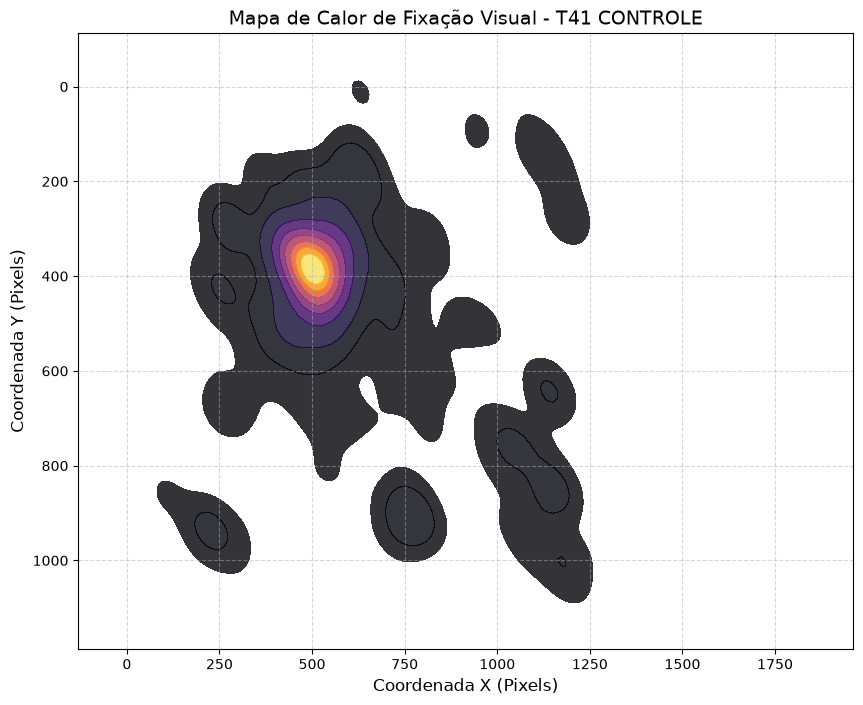

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

print("="*80)
print("NOTEBOOK 2: MAPEAMENTO ESPACIAL E CALIBRAÇÃO DE AOIs")
print("="*80)

PASTA_CSV = '/workspaces/EyeTracking/data/csv/'
arquivos_limpos = glob.glob(os.path.join(PASTA_CSV, '*.csv'))

# Vamos pegar o primeiro paciente CONTROLE da lista para calibrar a tela
arquivo_calibracao = None
for arq in arquivos_limpos:
    if 'CONTROLE' in arq.upper():
        arquivo_calibracao = arq
        break

nome_puro = os.path.basename(arquivo_calibracao).replace('.csv', '')
print(f"Utilizando paciente {nome_puro} para gerar o gabarito espacial...\n")

df = pd.read_csv(arquivo_calibracao)

# Filtramos apenas os momentos em que uma face (Humano ou Desenho) estava na tela
df_face = df[df['Fase_Estimulo'] == 'Exposicao_Face'].copy()

# Removemos ruídos onde o Gaze X ou Y não foi captado
df_face = df_face.dropna(subset=['Gaze_X', 'Gaze_Y'])

# Criação do Gráfico de Densidade (Heatmap)
plt.figure(figsize=(10, 8))

# Em Eye Tracking, a coordenada Y=0 é o TOPO da tela. Por isso, invertemos o eixo Y depois.
sns.kdeplot(
    x=df_face['Gaze_X'], 
    y=df_face['Gaze_Y'], 
    cmap="inferno", 
    fill=True, 
    thresh=0.05, 
    alpha=0.8
)

plt.title(f"Mapa de Calor de Fixação Visual - {nome_puro}", fontsize=14)
plt.xlabel("Coordenada X (Pixels)", fontsize=12)
plt.ylabel("Coordenada Y (Pixels)", fontsize=12)

# Inverter o eixo Y para simular a visão real do monitor
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

NOTEBOOK 3.5: ANÁLISE EXPLORATÓRIA CLÍNICA (EDA)


/tmp/ipykernel_16470/3583281226.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Grupo', y='Velocidade_Sacadica_Media', palette=cores_grupo, ax=axes[0])
/tmp/ipykernel_16470/3583281226.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Grupo', y='TTFF_Medio_Olhos_ms', palette=cores_grupo, ax=axes[1])
/tmp/ipykernel_16470/3583281226.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Grupo', y='EMI_Global', palette=cores_grupo, ax=axes[2])


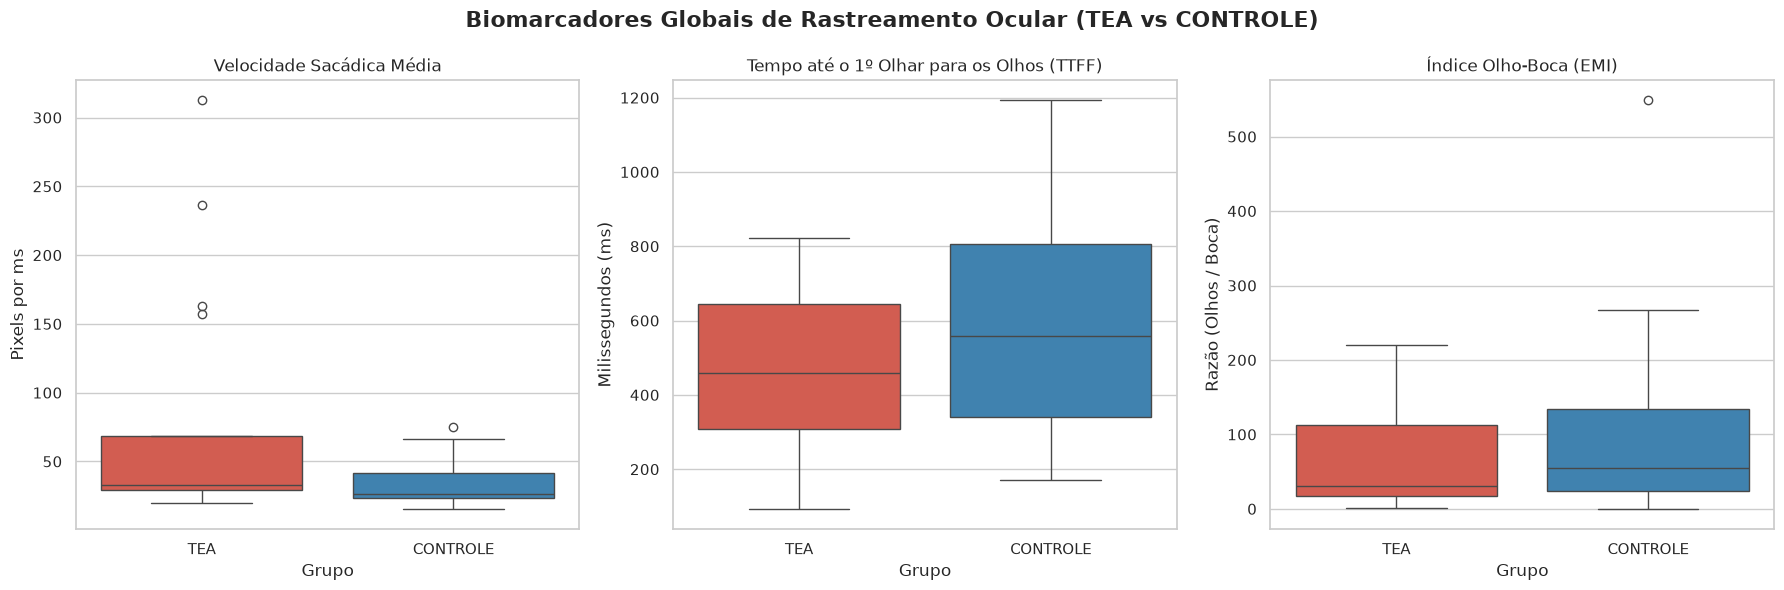

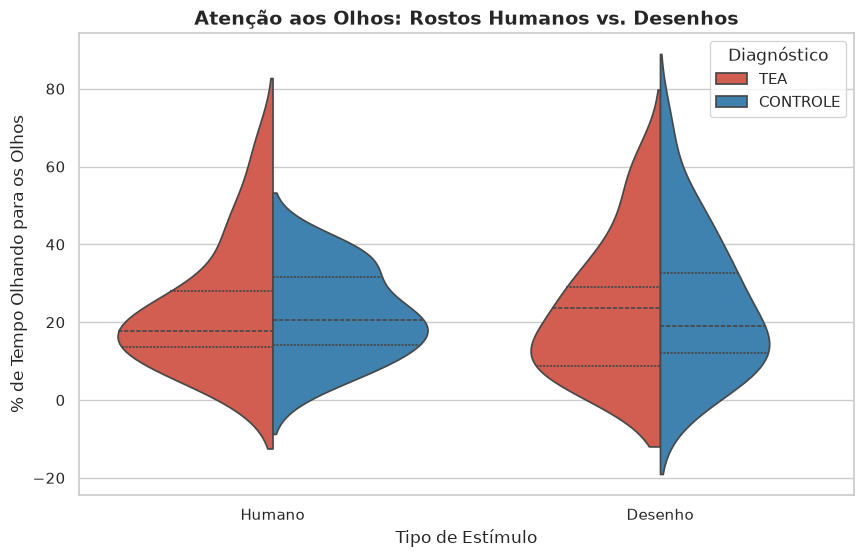

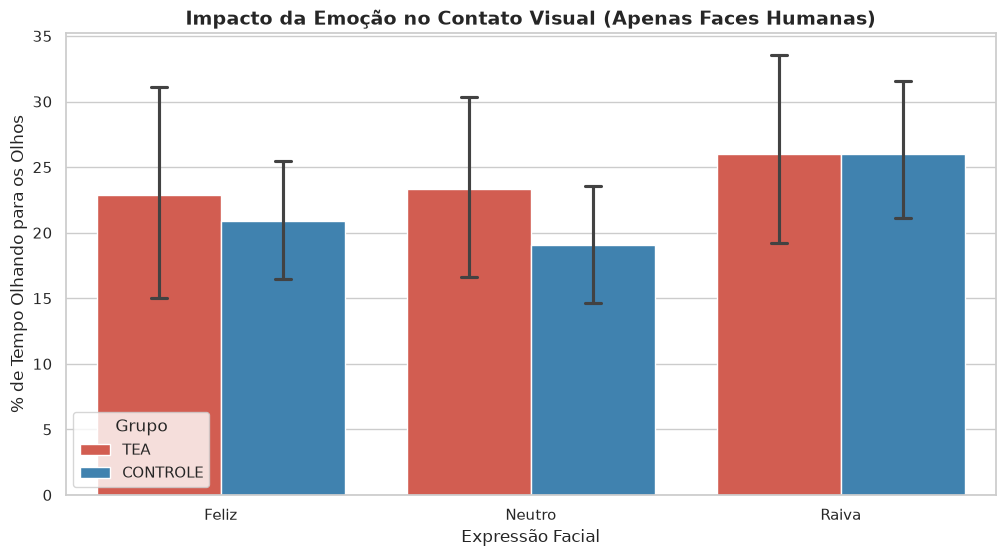

🎯 Gráficos gerados com sucesso.
Observe as diferenças de mediana (linhas nos boxplots/violinos) e a dispersão dos dados.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("NOTEBOOK 3.5: ANÁLISE EXPLORATÓRIA CLÍNICA (EDA)")
print("="*80)

# 1. Carregar a Matriz de Features
CAMINHO_MATRIZ = '/workspaces/EyeTracking/data/processed/matriz_features_ml.csv'
df = pd.read_csv(CAMINHO_MATRIZ)

# Configuração visual de alto padrão para artigos científicos
sns.set_theme(style="whitegrid")
cores_grupo = {'CONTROLE': '#2E86C1', 'TEA': '#E74C3C'} # Azul para Controle, Vermelho para TEA

# -------------------------------------------------------------------------
# GRÁFICO 1: Biomarcadores Clínicos Globais (Velocidade, TTFF e Índice Social)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Biomarcadores Globais de Rastreamento Ocular (TEA vs CONTROLE)", fontsize=16, fontweight='bold')

sns.boxplot(data=df, x='Grupo', y='Velocidade_Sacadica_Media', palette=cores_grupo, ax=axes[0])
axes[0].set_title("Velocidade Sacádica Média")
axes[0].set_ylabel("Pixels por ms")

sns.boxplot(data=df, x='Grupo', y='TTFF_Medio_Olhos_ms', palette=cores_grupo, ax=axes[1])
axes[1].set_title("Tempo até o 1º Olhar para os Olhos (TTFF)")
axes[1].set_ylabel("Milissegundos (ms)")

sns.boxplot(data=df, x='Grupo', y='EMI_Global', palette=cores_grupo, ax=axes[2])
axes[2].set_title("Índice Olho-Boca (EMI)")
axes[2].set_ylabel("Razão (Olhos / Boca)")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# GRÁFICO 2: Contraste de Atenção aos Olhos (Humanos vs Desenhos)
# -------------------------------------------------------------------------
# Vamos derreter (melt) o dataframe para colocar Humanos e Desenhos lado a lado
df_melt_tipo = pd.melt(df, id_vars=['Paciente', 'Grupo'], 
                       value_vars=['Humano_AOI_Ambos_Olhos_%', 'Desenho_AOI_Ambos_Olhos_%'],
                       var_name='Tipo_Estimulo', value_name='Tempo_Nos_Olhos_%')

# Limpar os nomes para o gráfico ficar bonito
df_melt_tipo['Tipo_Estimulo'] = df_melt_tipo['Tipo_Estimulo'].str.replace('_AOI_Ambos_Olhos_%', '')

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_melt_tipo, x='Tipo_Estimulo', y='Tempo_Nos_Olhos_%', hue='Grupo', 
               split=True, inner="quart", palette=cores_grupo)
plt.title("Atenção aos Olhos: Rostos Humanos vs. Desenhos", fontsize=14, fontweight='bold')
plt.ylabel("% de Tempo Olhando para os Olhos")
plt.xlabel("Tipo de Estímulo")
plt.legend(title="Diagnóstico")
plt.show()

# -------------------------------------------------------------------------
# GRÁFICO 3: Impacto das Emoções Humanas no Contato Visual
# -------------------------------------------------------------------------
df_melt_emocao = pd.melt(df, id_vars=['Paciente', 'Grupo'], 
                         value_vars=['Humano_Feliz_AOI_Ambos_Olhos_%', 
                                     'Humano_Neutro_AOI_Ambos_Olhos_%', 
                                     'Humano_Raiva_AOI_Ambos_Olhos_%'],
                         var_name='Emocao', value_name='Tempo_Nos_Olhos_%')

df_melt_emocao['Emocao'] = df_melt_emocao['Emocao'].str.replace('Humano_', '').str.replace('_AOI_Ambos_Olhos_%', '')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt_emocao, x='Emocao', y='Tempo_Nos_Olhos_%', hue='Grupo', 
            palette=cores_grupo, capsize=.1)
plt.title("Impacto da Emoção no Contato Visual (Apenas Faces Humanas)", fontsize=14, fontweight='bold')
plt.ylabel("% de Tempo Olhando para os Olhos")
plt.xlabel("Expressão Facial")
plt.show()

print("🎯 Gráficos gerados com sucesso.")
print("Observe as diferenças de mediana (linhas nos boxplots/violinos) e a dispersão dos dados.")
print("="*80)